# Example of Exploratory Data Analysis for a Regression Task

In this notebook, we perform an example of **exploratory data analysis (EDA)** for a regression problem.  
Our final objective is to understand the dataset, clean it when necessary, identify useful variables, and prepare the data for a simple **linear regression model**.

We will proceed step by step:

1. load and inspect the data  
2. check data quality issues  
3. study numerical and categorical variables 
4. summarize the distributions via centrality and disperion measures
5. perfomr EDA to understand the phenomenon and the relation between variables  
6. study correlation between variables
7. detect possible outliers  (mind preprocessing/transformation)
8. prepare the dataset for regression (mind preprocessing/transformation) 
9. evaluate the model results

The goal is not only to run the code, but also to understand **why each step is useful**.

## 1. Loading the data

We begin by importing the main Python libraries used in this notebook.

Then define an easy 2d PCA plot function. 

After that, we load the dataset and focus on a subset of interest: **Audi cars**.  
Working on a subset can make the analysis more homogeneous and easier to interpret.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

def plot_pca(df, n_components=2, figsize=(10, 8), random_state=42, c='k'):
    """
    Perform PCA on a pandas DataFrame and plot the results.
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing the rescaled numerical features
    n_components : int, optional
        Number of principal components to compute (default: 2)
                    figsize : tuple, option
        Figure size for the plot (default: (10, 8))
    random_state : int, optional
        Random state for reproducibility (default: 42)
    """
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=['float64', 'int64'])
    
    # Perform PCA
    pca = PCA(n_components=n_components, random_state=random_state)
    principal_components = pca.fit_transform(numeric_df)
    
    # Create a DataFrame with the principal components
    pc_df = pd.DataFrame(
        data=principal_components,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    
    # Calculate explained variance
    explained_variance = pca.explained_variance_ratio_ * 100
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Scatter plot of the first two PCs
    if n_components >= 2:
        sns.scatterplot(x='PC1', y='PC2', data=pc_df, c=c)
        
        plt.xlabel(f'PC1 ({explained_variance[0]:.2f}%)')
        plt.ylabel(f'PC2 ({explained_variance[1]:.2f}%)')
        plt.title('PCA of Rescaled Features')
        
        # Add a tight grid
        plt.grid(True, linestyle='--', alpha=0.7)
        
    # Show the plot
    plt.tight_layout()
    plt.show()
    
    # Print explained variance information
    print(f'Total explained variance: {sum(explained_variance):.2f}%')
    for i, variance in enumerate(explained_variance):
        print(f'PC{i+1}: {variance:.2f}%')
    
    return pca, pc_df

In [2]:
###IMPORT DATA

#from google.colab import drive
#drive.mount('/content/drive')
#import os
#os.chdir('/content/drive/MyDrive/Colab_Notebooks/BDA')

##!kaggle datasets download -d aishwaryamuthukumar/cars-dataset-audi-bmw-ford-hyundai-skoda-vw
##!unzip /content/drive/MyDrive/yourpath/cars-dataset-audi-bmw-ford-hyundai-skoda-vw.zip


In [3]:
df=pd.read_csv('cars_dataset.csv')
df_audi=df.loc[df['Make']=='audi']

## 2. First inspection of the dataset

Before building any model, it is important to understand the dataset structure.

In this phase, we ask a few basic questions:

- How many observations do we have?
- Which variables types are present?
- Are there missing values?
- Do some variables contain suspicious values?

This first inspection often reveals data quality problems that should be addressed early.

In [4]:
print('Let us print some info about the dataset')
df_audi.info()

Let us print some info about the dataset
<class 'pandas.core.frame.DataFrame'>
Index: 10668 entries, 0 to 10667
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10668 non-null  object 
 1   year          10668 non-null  int64  
 2   price         10668 non-null  int64  
 3   transmission  10668 non-null  object 
 4   mileage       10668 non-null  int64  
 5   fuelType      10668 non-null  object 
 6   tax           10668 non-null  float64
 7   mpg           10668 non-null  float64
 8   engineSize    10668 non-null  float64
 9   Make          10668 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 916.8+ KB


In [5]:
print('Apparently there are no missing values')
df.isna().sum()

Apparently there are no missing values


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

In [6]:
print('however, looking at the description of the numerical attributes we see that the engine size minimum has a problem')
df_audi.describe()

however, looking at the description of the numerical attributes we see that the engine size minimum has a problem


,year,price,mileage,tax,mpg,engineSize
count,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000
mean,2017.100675,22896.685039,24827.244001,126.011436,50.770022,1.930709
std,2.167494,11714.841888,23505.257205,67.170294,12.949782,0.602957
min,1997.000000,1490.000000,1.000000,0.000000,18.900000,0.000000
25%,2016.000000,15130.750000,5968.750000,125.000000,40.900000,1.500000
50%,2017.000000,20200.000000,19000.000000,145.000000,49.600000,2.000000
75%,2019.000000,27990.000000,36464.500000,145.000000,58.900000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,188.300000,6.300000


In [7]:
print('For this reason we filter out problematic records with vanishing engineSize')
df_audi=df_audi.loc[df_audi['engineSize']>0,:]

For this reason we filter out problematic records with vanishing engineSize


## 3. Plotting variable distributions

A good EDA always includes visual inspection of the variables.

For numerical variables, distributions help us understand:

- the typical range of values
- whether the variable is symmetric or skewed
- whether there are extreme values
- whether transformations might be useful later

At this stage, we are not making final decisions yet: we are simply trying to build intuition about the data.

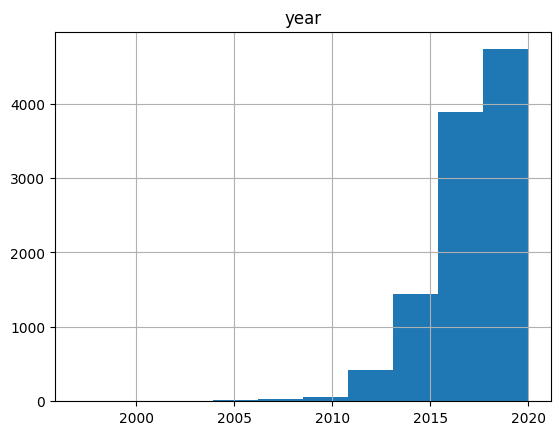

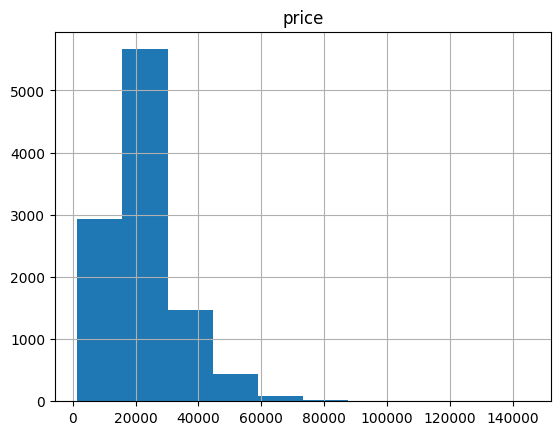

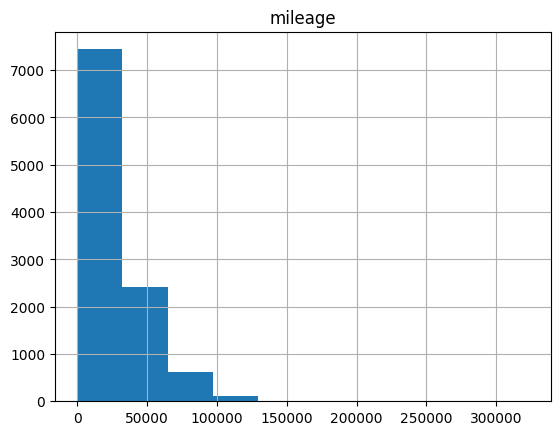

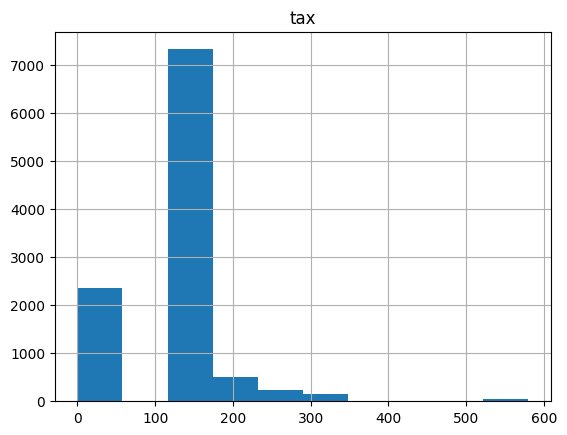

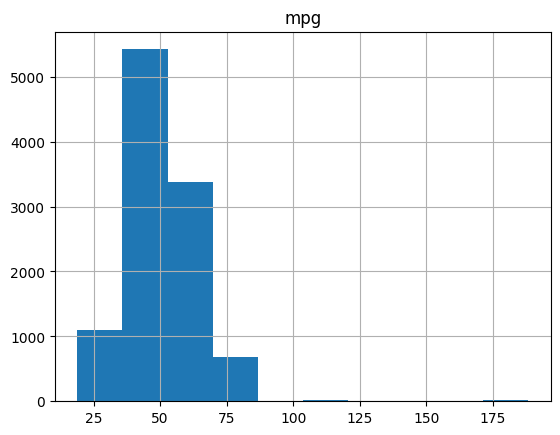

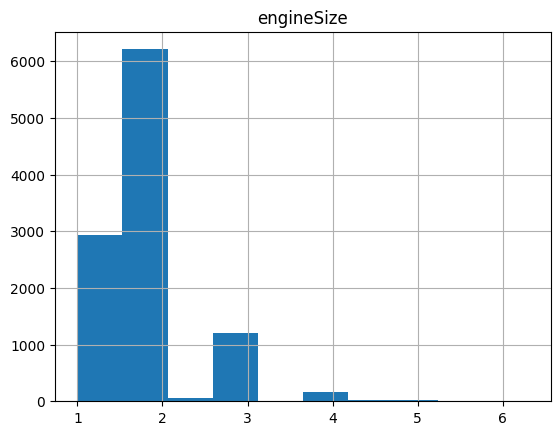

In [8]:
## plot distribution
for column in df_audi.columns:
  if df_audi[column].dtypes in ['int64','float64']:
    df_audi[column].hist()
    plt.title(column)
    plt.show()

## 4. Central tendency and dispersion

Plots are very useful, but numerical summaries are equally important.

Here we compute simple statistics describing centrality and dispersion. 

These summaries are especially helpful when distributions are skewed or contain outliers, because they are more robust than the mean and standard deviation.

In [9]:
for col in ['year', 'price', 'mileage',  'tax', 'mpg', 'engineSize']: 
    print(f'Feature {col}: median {df_audi[col].median()}, IQR: [{df_audi[col].quantile(0.25)},{df_audi[col].quantile(0.75)}]')
for col in ['model',  'transmission', 'fuelType']: 
    print(f'Feature {col}: mode {df_audi[col].mode()[0]}, no dispersion measure as it is nominal')

Feature year: median 2017.0, IQR: [2016.0,2019.0]
Feature price: median 20000.0, IQR: [15000.0,27990.0]
Feature mileage: median 19118.0, IQR: [6000.0,36547.0]
Feature tax: median 145.0, IQR: [125.0,145.0]
Feature mpg: median 49.6, IQR: [40.9,58.9]
Feature engineSize: median 2.0, IQR: [1.5,2.0]
Feature model: mode  A3, no dispersion measure as it is nominal
Feature transmission: mode Manual, no dispersion measure as it is nominal
Feature fuelType: mode Diesel, no dispersion measure as it is nominal


## 5. Exploratory analysis of individual variables

We now explore the variables in more detail.

For categorical variables, we look at the frequency of each category.  
For numerical variables, we inspect how values are distributed across time and across the target variable.

This step is useful because it helps us answer questions such as:

- Which car models are most frequent?
- Are some years better represented than others?
- Do transmission and fuel type change over time?
- Does price show a clear pattern across models?

<Figure size 1500x500 with 0 Axes>

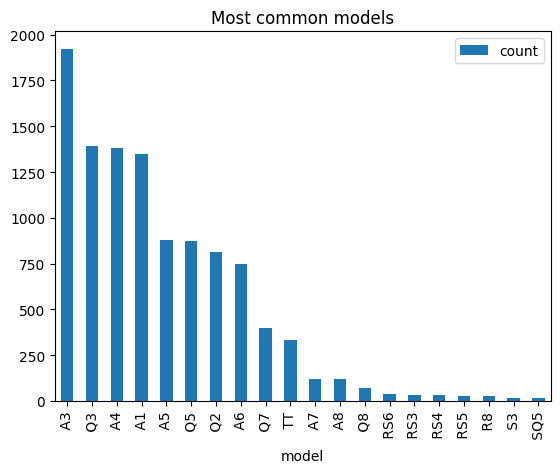

In [10]:
### LET'S PERFORM A LITTLE EDA
## inspect car model 
m = df_audi["model"].value_counts().reset_index().head(20)
plt.figure(figsize=(15,5))
m.plot(kind='bar',x="model",y="count")
plt.title("Most common models")
plt.show()

<Figure size 1500x500 with 0 Axes>

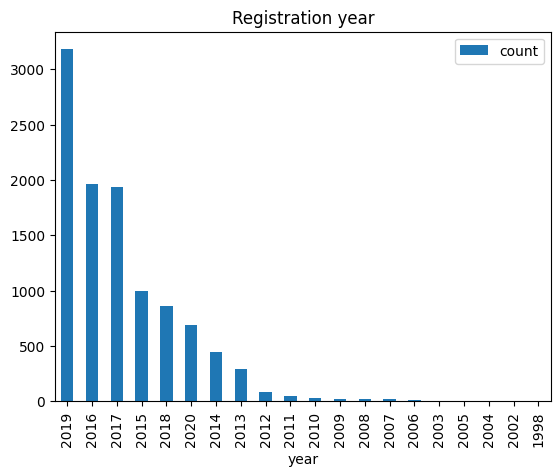

In [11]:
## inspect registration year variable
m = df_audi["year"].value_counts().reset_index().head(20)
plt.figure(figsize=(15,5))
m.plot(kind='bar',x="year",y="count")
plt.title("Registration year")
plt.show()

<Figure size 2000x1000 with 0 Axes>

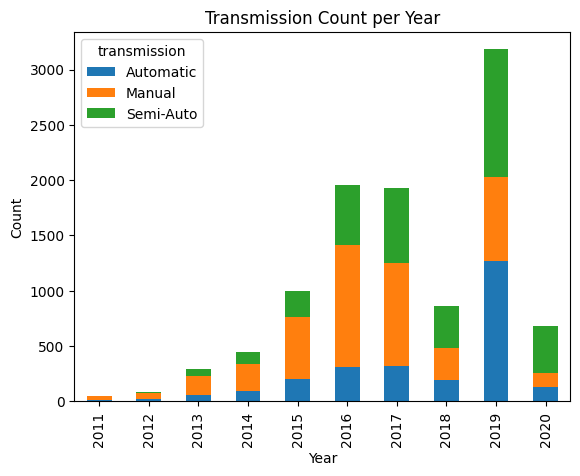

In [12]:
## inspect distribution of transmission variable per year

plt.figure(figsize=(20,10))
df_audi_cut=df_audi.loc[df_audi['year']>2010]
grouped_data = df_audi_cut.groupby(["year", "transmission"]).size().unstack(fill_value=0)

# Plot the count for each transmission category by year
grouped_data.plot(kind="bar", stacked=True)

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Transmission Count per Year")
plt.show()

<Figure size 2000x1000 with 0 Axes>

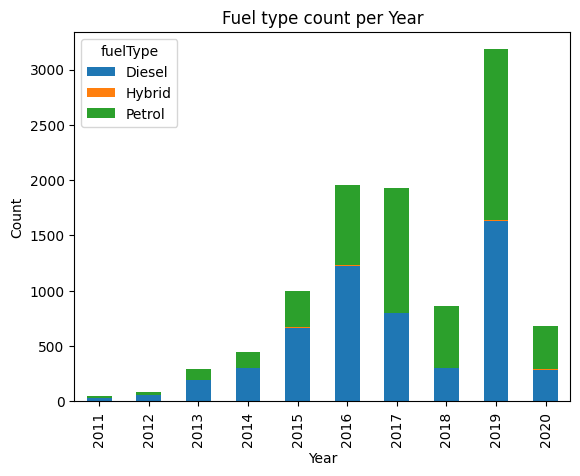

In [13]:
## inspect distribution of fuel type variable per year

plt.figure(figsize=(20,10))
df_audi_cut=df_audi.loc[df_audi['year']>2010]
grouped_data = df_audi_cut.groupby(["year", "fuelType"]).size().unstack(fill_value=0)

# Plot the count for each transmission category by year
grouped_data.plot(kind="bar", stacked=True)

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Fuel type count per Year")
plt.show()

16 models have at least 30 observations. Plotting their boxplot.


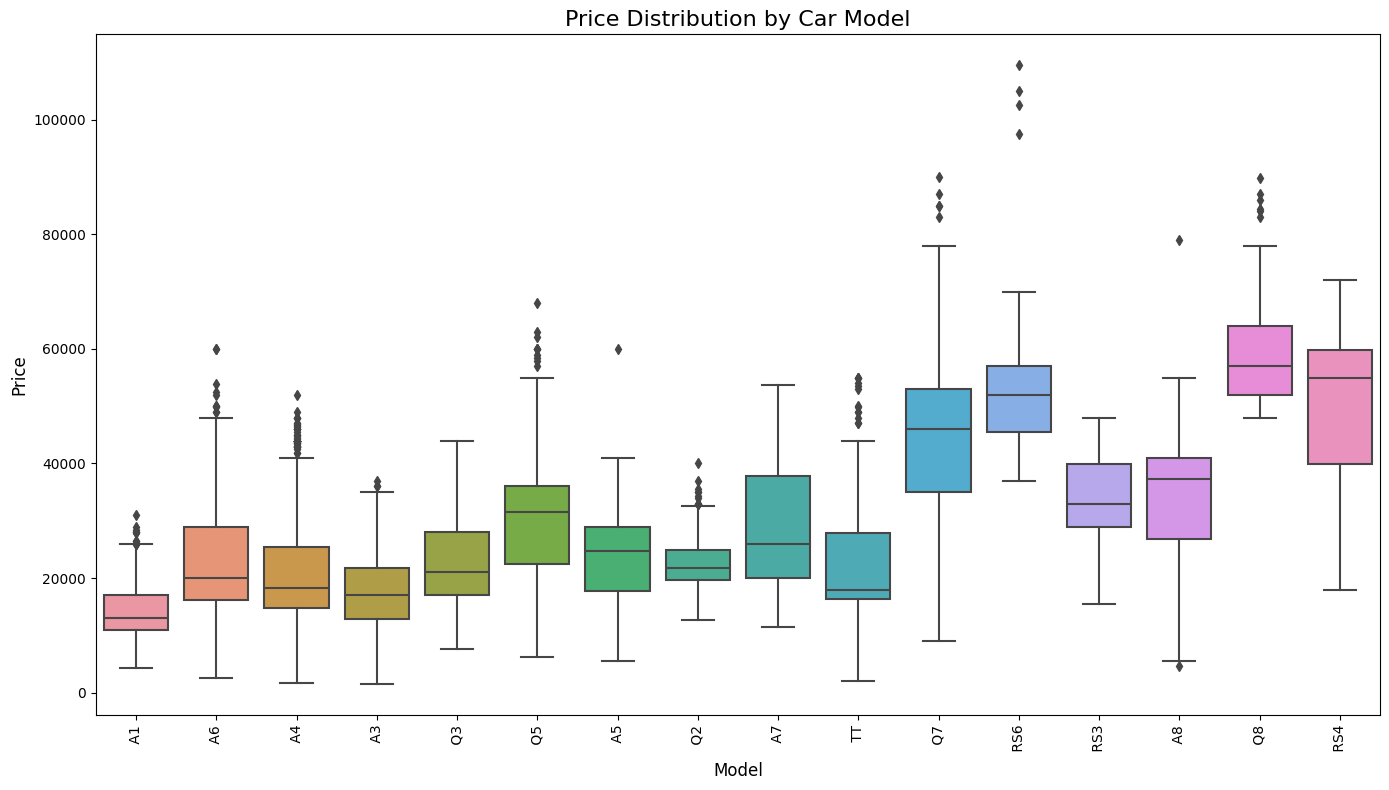

From the boxplt, we clearly see that for almost every model the price 
attribute has a heavy right tail. We may ask ourself if by applying a log 
transformation things may get better (more symmetric). We do this as our 
final task is prediction, and we need to start understanding which 
transfomration makes price more well behaved.


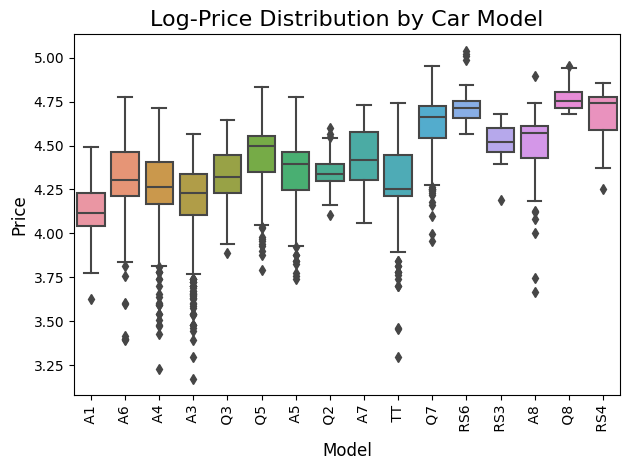

As it is easy to see the logarithm is too much for price: we are getting negatively 
skewed distributions. It already suggests me that I should use BoxCox transformation later.


In [14]:
import seaborn as sns
min_count=30


# Set the figure size for better visibility
plt.figure(figsize=(14, 8))
model_counts = df_audi['model'].value_counts()
# Filter models that appear more than min_count times
frequent_models = model_counts[model_counts >= min_count].index.tolist()
# Create a filtered dataframe with only these frequent models
df_filtered = df_audi[df_audi['model'].isin(frequent_models)].copy()
# Get the count of models that meet the criteria


print(f'{len(frequent_models)} models have at least {min_count} observations. Plotting their boxplot.')

# Create the boxplot using seaborn
ax = sns.boxplot(x='model', y='price', data=df_filtered)

# Improve readability by rotating x-axis labels
plt.xticks(rotation=90)

# Add title and labels
plt.title('Price Distribution by Car Model', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Price', fontsize=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

print(f'From the boxplt, we clearly see that for almost every model the price ' \
'\nattribute has a heavy right tail. We may ask ourself if by applying a log ' \
'\ntransformation things may get better (more symmetric). We do this as our ' \
'\nfinal task is prediction, and we need to start understanding which ' \
'\ntransfomration makes price more well behaved.')


df_filtered['log_price']=np.log10(df_filtered['price'])

# Create the boxplot using seaborn
ax = sns.boxplot(x='model', y='log_price', data=df_filtered)

# Improve readability by rotating x-axis labels
plt.xticks(rotation=90)

# Add title and labels
plt.title('Log-Price Distribution by Car Model', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Price', fontsize=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


print('As it is easy to see the logarithm is too much for price: we are getting negatively ' \
'\nskewed distributions. It already suggests me that I should use BoxCox transformation later.')



## 6. Relationships between numerical variables

We now study how the numerical variables are related to one another and to the target variable, `price`.

Scatter plots give a visual overview of these relationships.  
However, not all relationships are linear, and some variables are skewed or may be affected by outliers.

For this reason, in addition to visual inspection, we also consider **Spearman correlation**, which measures **monotonic association** and is often more appropriate than Pearson correlation in this setting.

[]

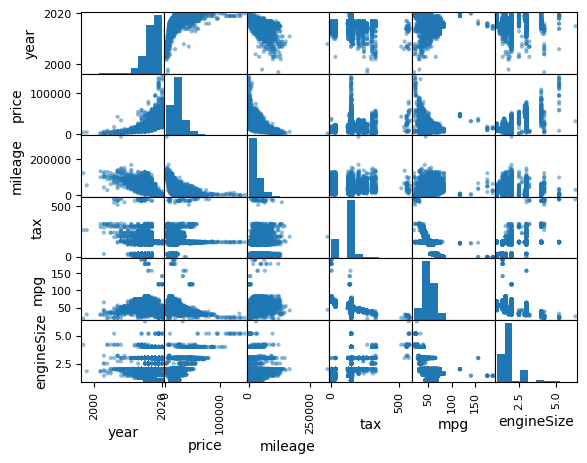

In [15]:
# inspect scatterplots between continuous variables
# as you can see there are no linear correlations around... we will use spearman
pd.plotting.scatter_matrix(df_audi[['year', 'price', 'mileage','tax',
       'mpg', 'engineSize']])
plt.plot()

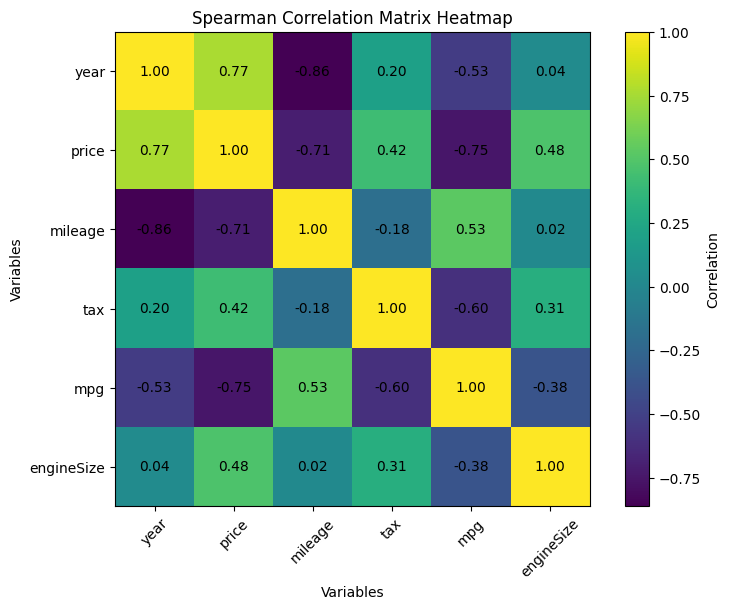

year, mileage and miles per gallon exhibit a strong correlation with the target. 
We have some chances to construct a decent regression model


In [16]:
## Let us now think about numerical variables, do they correlate with the target (price)? Looking at the scatter plot
## using sperman correlation coefficient may be better (non linear relations in the scatter plots)
corr_spearman=df_audi[['year', 'price', 'mileage','tax',
       'mpg', 'engineSize']].corr(method='spearman')

## Plot correlation using a heatmap
plt.figure(figsize=(8, 6))
plt.imshow(corr_spearman, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Correlation')
plt.title('Spearman Correlation Matrix Heatmap')
# Annotate cells with correlation values
for i in range(len(corr_spearman)):
    for j in range(len(corr_spearman)):
        plt.text(j, i, f"{corr_spearman.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.xticks(ticks=np.arange(len(corr_spearman.columns)), labels=corr_spearman.columns, rotation=45)
plt.yticks(ticks=np.arange(len(corr_spearman.columns)), labels=corr_spearman.columns)
plt.tight_layout()
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.show()

print('year, mileage and miles per gallon exhibit a strong correlation with the target. \nWe have some chances to construct a decent regression model')

## Our objective is a regression task (predict price). 
For this reason we first split the data into a trining and a test set. Then proceed with outlier detection and feature transformation for predictive purposes. 

### First however, we transform categorical variables into numerical ones to avoid future encoding problem. 

The variable `model` contains many categories, and using each one directly may produce too many sparse indicators.

Instead, we create broader groups based on the model series (for example, A, Q, S, RS, and so on).  
This is a simple example of **feature engineering**: we use domain knowledge to create variables that may be more informative / easier to interpret / easier to use from a statistical point of view.


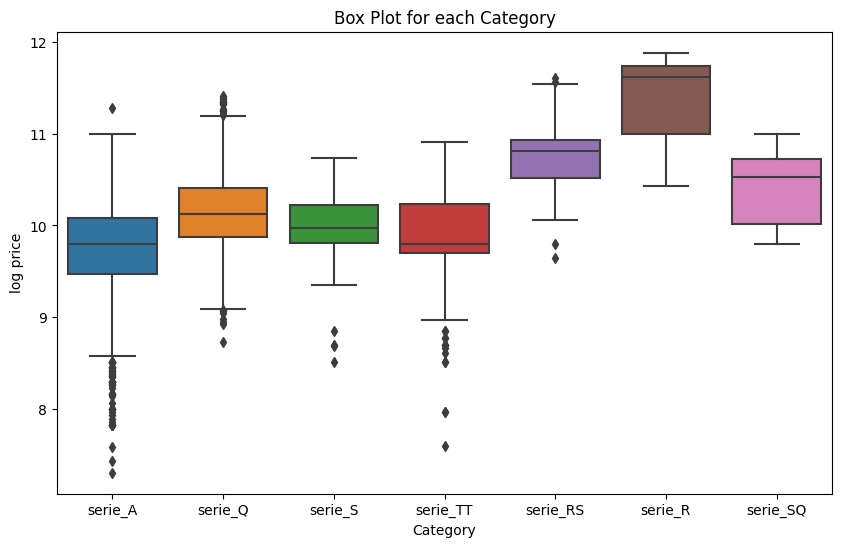

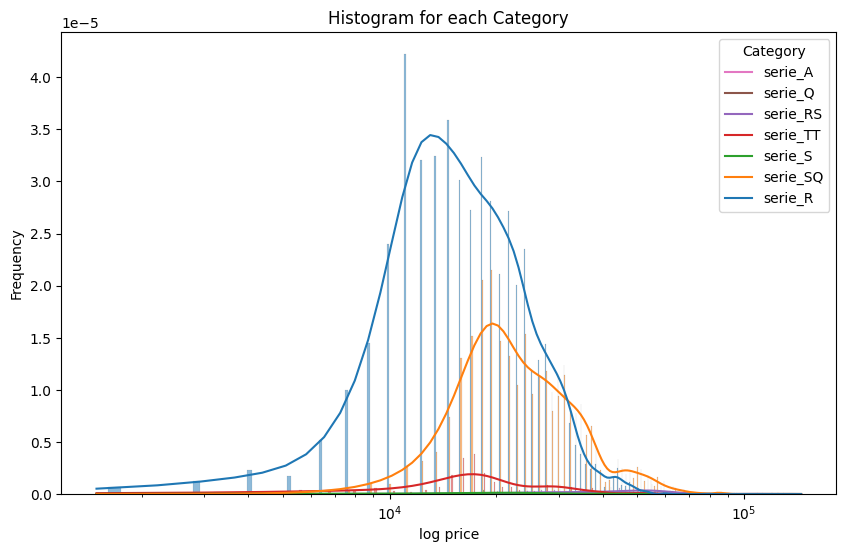

In [17]:


# Nominal attribute dummification (drop first because it's a regression task)
df_audi = pd.get_dummies(df_audi,columns=["fuelType"],drop_first=True,dtype='i',)
df_audi = pd.get_dummies(df_audi,columns=["transmission"],drop_first=True,dtype='i')

## Feature creation: models may be too many, try using the series
# Initialize all series to 0
df_audi[['serie_A', 'serie_Q', 'serie_RS', 'serie_TT', 'serie_S', 'serie_SQ', 'serie_R']] = 0

# Set corresponding series to 1 based on model content
df_audi[['serie_A', 'serie_Q', 'serie_RS', 'serie_TT', 'serie_S', 'serie_SQ', 'serie_R']]=0
df_audi.loc[df_audi['model'].str.contains('A'),'serie_A']=1
df_audi.loc[df_audi['model'].str.contains('RS'),'serie_RS']=1
df_audi.loc[df_audi['model'].str.contains('TT'),'serie_TT']=1
df_audi.loc[df_audi['model'].str.contains('SQ'),'serie_SQ']=1
df_audi.loc[df_audi['model'].str.contains('Q') & (~ df_audi['model'].str.contains('SQ')),'serie_Q']=1
df_audi.loc[df_audi['model'].str.contains('S') & (~ df_audi['model'].str.contains('SQ')) & (~ df_audi['model'].str.contains('RS')),'serie_S']=1
df_audi.loc[df_audi['model'].str.contains('R') & (~ df_audi['model'].str.contains('RS')),'serie_R']=1


## Are the series meaningful? Plot differences via box plot.
## MIND not all points are real outliers!!!

import seaborn as sns
# Get the column name where the value is 1
result = df_audi[['serie_A', 'serie_Q', 'serie_RS', 'serie_TT', 'serie_S', 'serie_SQ', 'serie_R']].idxmax(axis=1)
# Create a new DataFrame with the result
result_df = pd.DataFrame({'serie': result})


plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.boxplot(data=pd.concat([result_df,np.log(df_audi['price'])],axis=1), x='serie', y='price')
plt.title('Box Plot for each Category')
plt.xlabel('Category')
plt.ylabel('log price')
plt.show()


plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.histplot(data=pd.concat([result_df,df_audi['price']],axis=1), x='price', hue='serie', multiple='dodge', shrink=0.8, kde=True, stat='density')
plt.title('Histogram for each Category')
plt.legend(['serie_A', 'serie_Q', 'serie_RS', 'serie_TT', 'serie_S', 'serie_SQ', 'serie_R'],title='Category', loc='upper right')
plt.xlabel('log price')
plt.ylabel('Frequency')
plt.xscale('log')
plt.show()

### Then proceed to train test split

Now that the main exploratory work and feature preparation are complete, we split the data into:

- a **training set**, used to fit the model
- a **test set**, used to evaluate how well the model generalizes to unseen data

Keeping the test set separate is essential: it gives us a more honest estimate of the final predictive performance.

In [18]:
from sklearn.model_selection import train_test_split

data_train, data_test = train_test_split(df_audi, test_size=0.3, random_state=0)

## 7. Outlier detection

Outliers are observations that differ strongly from the general structure of the data.

They are important because they can:

- distort summary statistics
- affect correlations
- have a strong influence on regression models
- sometimes reveal data quality problems

In this notebook, we compare two different unsupervised approaches:

- **DBSCAN**, a density-based clustering method
- **Local Outlier Factor (LOF)**, which compares the local density of a point with that of its neighbors

The goal is not to find a universally correct answer, but to reason about which method seems more convincing for this dataset.

Note that both methods work better with "isotropic" distributions: the data need to be scaled to meet this assumption as much as possible


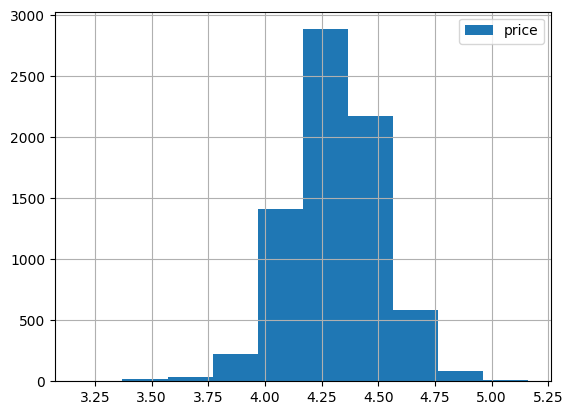

As we already saw, the log transformation may be too much. Moreover different vars have different balancing


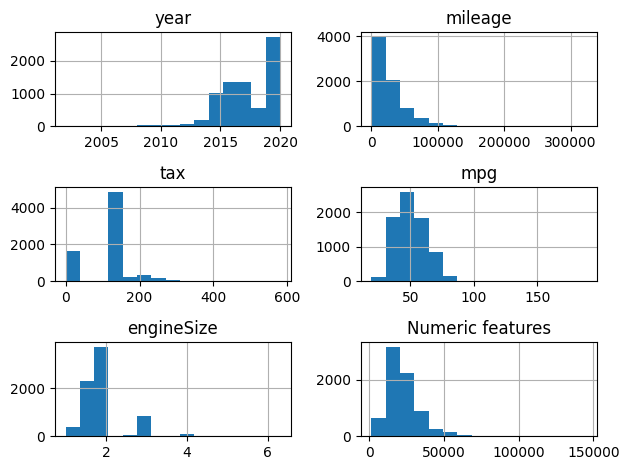

For this reason, we first use a box cox transformation. Afterward, as different vars 
span different orders of magnitude we standardize the values. 
Transform and rescale to make distribution similar and avoid units of measure effects 


In [19]:
# Now we need to think about outliers and study the numeric variables.
# Let us first look at the variable distributions

numeric_vars=['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']

np.log10(data_train['price']).hist(label='price')
plt.legend()
plt.show()

print('As we already saw, the log transformation may be too much. Moreover different vars have different balancing')

data_train[numeric_vars].hist(bins=15)
plt.title('Numeric features')
plt.tight_layout()
plt.show()


print('For this reason, we first use a box cox transformation. Afterward, as different vars \nspan different orders of magnitude we standardize the values. ')
print('Transform and rescale to make distribution similar and avoid units of measure effects ')

/Users/veronicaguidetti/miniforge3/envs/PACS/lib/python3.11/site-packages/scipy/stats/_morestats.py:1153: UserWarning: The optimal lambda is 355.61196093167723, but the returned lambda is the constrained optimum to ensure that the maximum or the minimum of the transformed data does not overflow in <class 'numpy.float64'>.
  lmax = boxcox_normmax(x, method='mle', optimizer=optimizer)


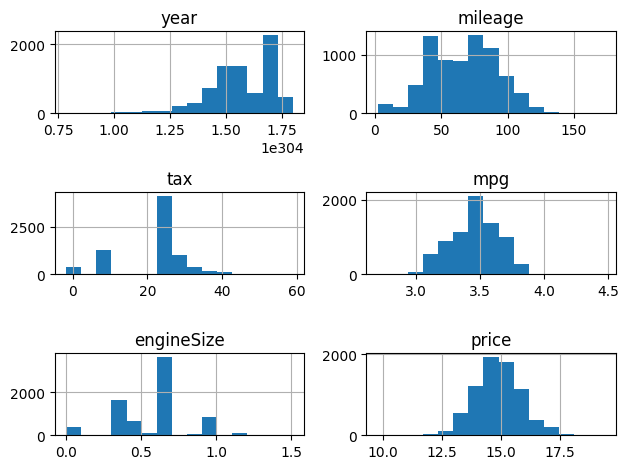

The outcome for year is terrible but we do not care at the moment. Let us now rescale the data


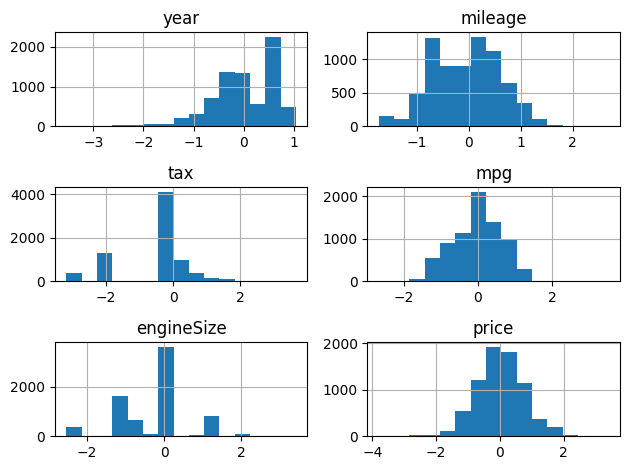

In [20]:
from scipy import stats

transformed_df = data_train[numeric_vars].copy()
lambda_dict={}
# Apply Box-Cox transformation 
for col in numeric_vars:
    # Perform Box-Cox transformation
    min_val = transformed_df[col].min()
    if min_val<=0:
        shift=-min_val+1e-4
    else:
        shift=0
    new_values, lambda_val = stats.boxcox(transformed_df[col]+shift)

    lambda_dict[col]=lambda_val
    transformed_df[col] = new_values

transformed_df.hist(bins=15)
plt.tight_layout()
plt.show()

print('The outcome for year is terrible but we do not care at the moment. Let us now rescale the data')


# Apply RobustScaler transformation
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
transformed_real_cov = pd.DataFrame(scaler.fit_transform(transformed_df[numeric_vars]))
transformed_real_cov.columns=numeric_vars

transformed_real_cov['tax']=transformed_real_cov['tax']/4

transformed_real_cov.hist(bins=15)
plt.tight_layout()
plt.show()





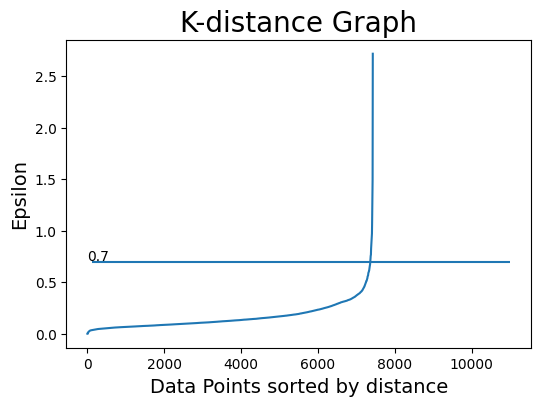

Value Counts:
-1: 146
0: 857
1: 222
2: 683
3: 4451
4: 561
5: 244
6: 33
7: 53
8: 99
9: 30
10: 14
11: 14
12: 20


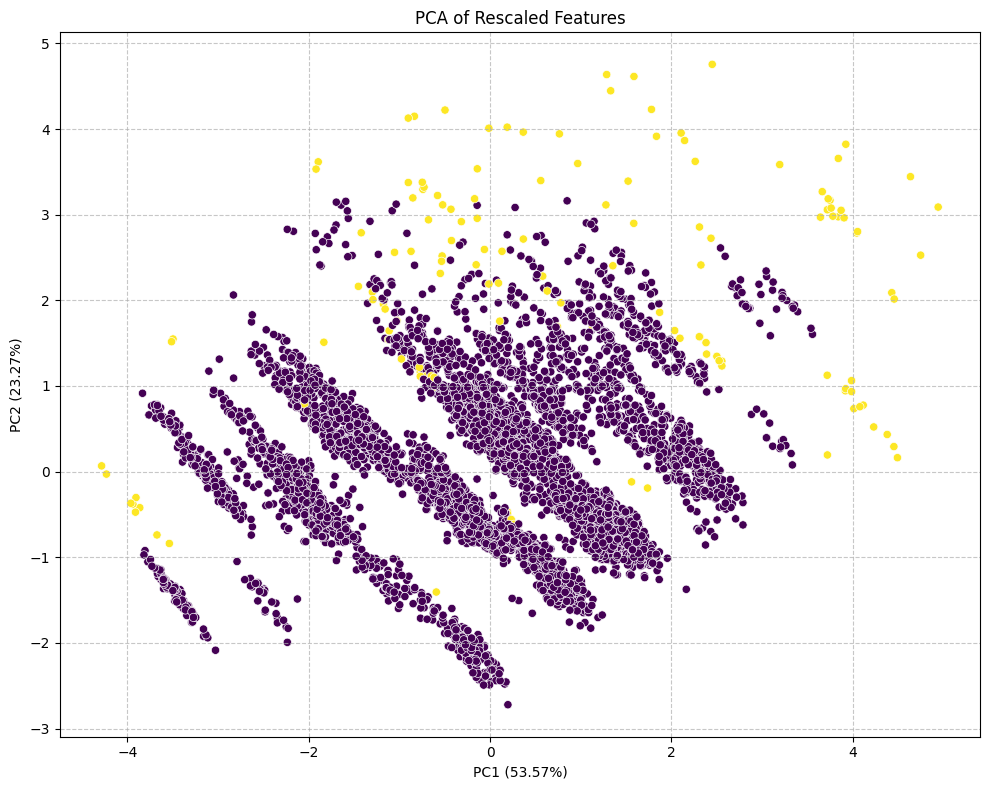

Total explained variance: 76.84%
PC1: 53.57%
PC2: 23.27%


In [21]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(transformed_real_cov)
distances, indices = nbrs.kneighbors(transformed_real_cov)
# Plotting K-distance Graph
distances = np.sort(distances, axis=0)
distances = distances[:,-1]
plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title('K-distance Graph',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14,color='k')
plt.hlines(0.7,11000,125)
plt.text(0, .75, '0.7', ha ='left', va ='center')
plt.show()


min_samples=2*len(numeric_vars)
eps=0.7
model = DBSCAN(eps = eps, min_samples = min_samples).fit(transformed_real_cov)
labels = model.labels_
outliers_DBSCAN=(labels==-1).astype(int)


# Get unique values and their counts
unique_values, counts = np.unique(labels, return_counts=True)

# Create a dictionary to store the counts of each value
value_counts = dict(zip(unique_values, counts))

# Print the value counts
print("Value Counts:")
for value, count in value_counts.items():
    print(f"{value}: {count}")



plot_pca(transformed_real_cov, n_components=2, figsize=(10, 8), random_state=42, c=outliers_DBSCAN)
plt.show()

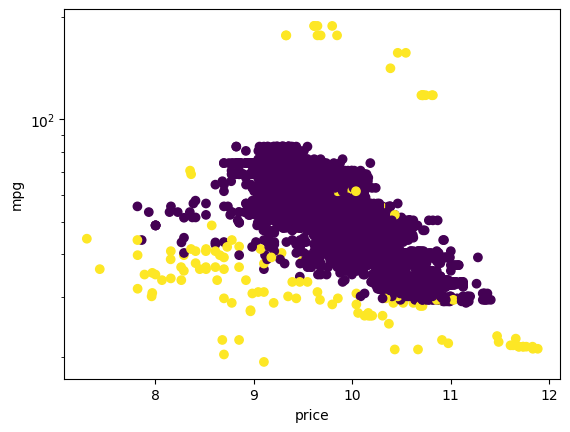

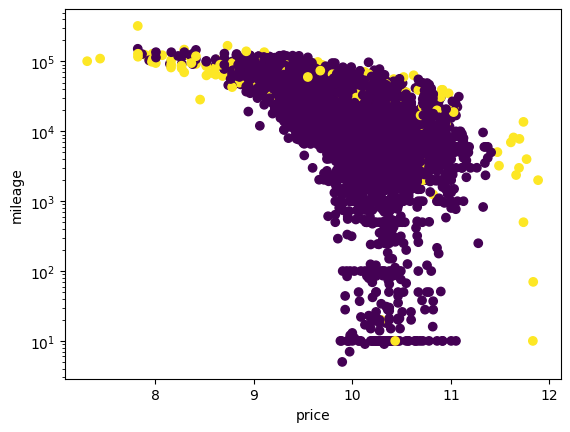

In [22]:
## let us look at the outliers in the original data distribution
plt.scatter(np.log(data_train['price']),data_train['mpg'],c=outliers_DBSCAN)
plt.yscale('log')
plt.xlabel('price')
plt.ylabel('mpg')
plt.show()


## let us look at the outliers in the original data distribution
plt.scatter(np.log(data_train['price']),data_train['mileage'],c=outliers_DBSCAN)
plt.yscale('log')
plt.xlabel('price')
plt.ylabel('mileage')
plt.show()



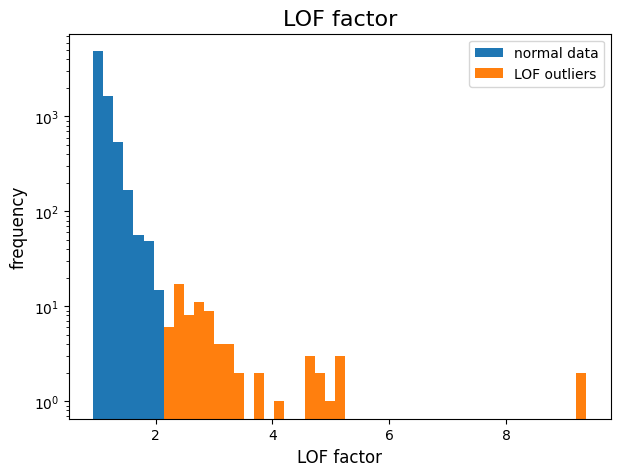

Based on the LOF distribution I would reconsider LOF_SCORES>4


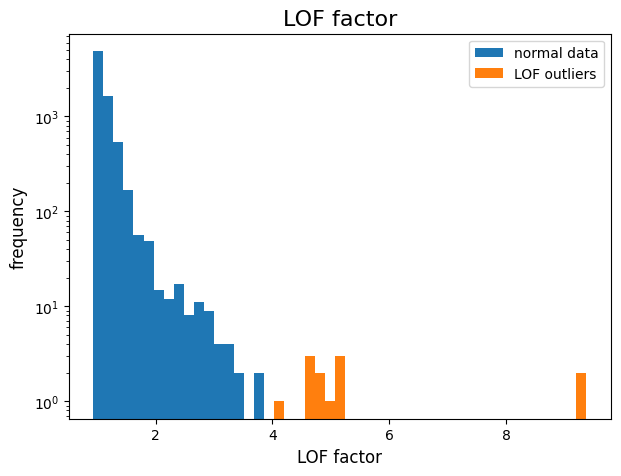

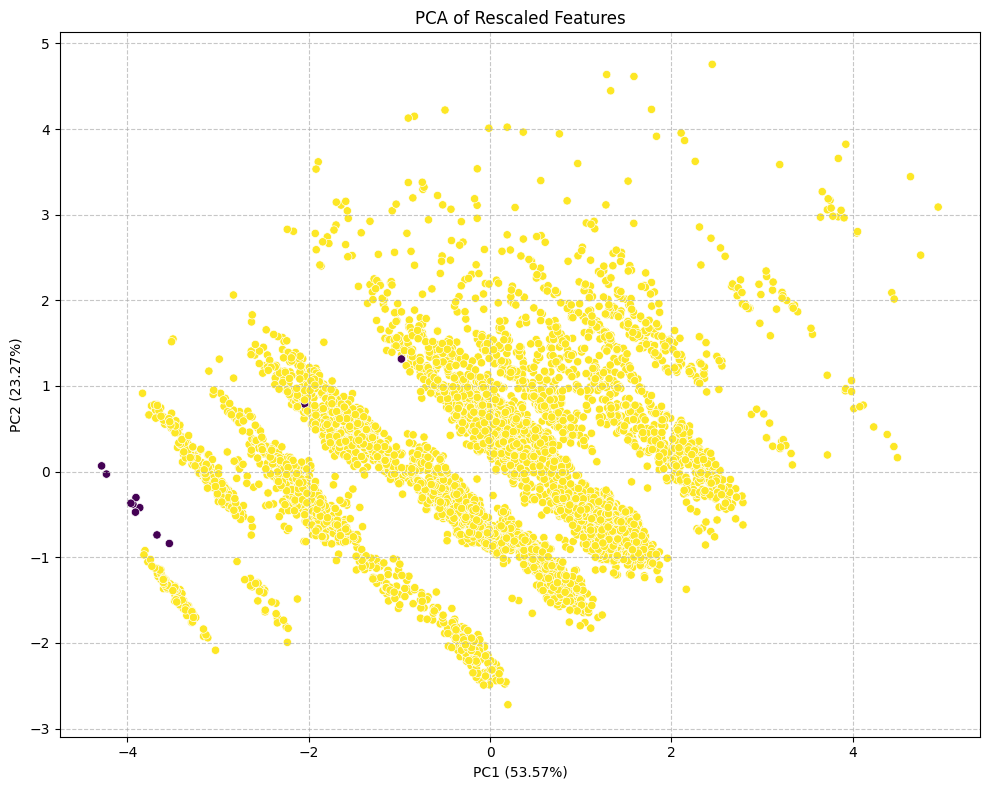

Total explained variance: 76.84%
PC1: 53.57%
PC2: 23.27%


In [23]:
from sklearn.neighbors import LocalOutlierFactor

# fit the model for outlier detection (default)
lof = LocalOutlierFactor(novelty=False,contamination=0.01)
labels = lof.fit_predict(transformed_real_cov)

#plot LOF scores
lof_scores=-lof.negative_outlier_factor_

plt.figure(figsize=(7,5))
plt.hist(lof_scores[labels>-1],bins=np.linspace(min(lof_scores), max(lof_scores), 50),label='normal data')
plt.hist(lof_scores[labels==-1],bins=np.linspace(min(lof_scores), max(lof_scores), 50),label='LOF outliers')
plt.xlabel('LOF factor',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.title('LOF factor',fontsize=16)
plt.legend()
plt.yscale('log')
plt.show()

print('Based on the LOF distribution I would reconsider LOF_SCORES>4')
labels = -1*(lof_scores>4).astype(int)

plt.figure(figsize=(7,5))
plt.hist(lof_scores[labels>-1],bins=np.linspace(min(lof_scores), max(lof_scores), 50),label='normal data')
plt.hist(lof_scores[labels==-1],bins=np.linspace(min(lof_scores), max(lof_scores), 50),label='LOF outliers')
plt.xlabel('LOF factor',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.title('LOF factor',fontsize=16)
plt.legend()
plt.yscale('log')
plt.show()


plot_pca(transformed_real_cov, n_components=2, figsize=(10, 8), random_state=42, c=labels)
plt.show()

outliers_LOF =(labels==-1).astype(int)


12


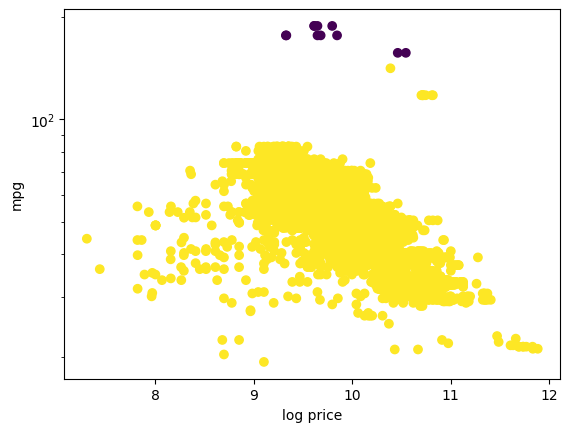

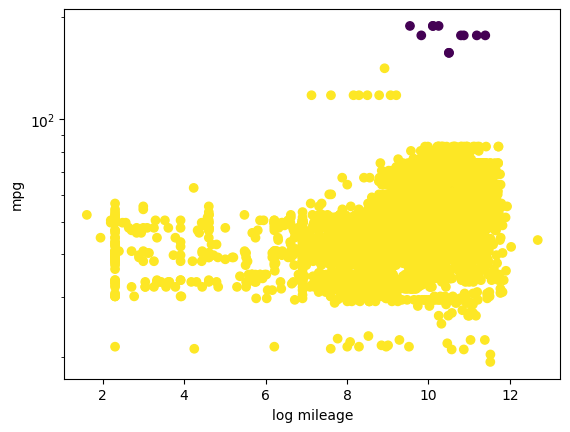

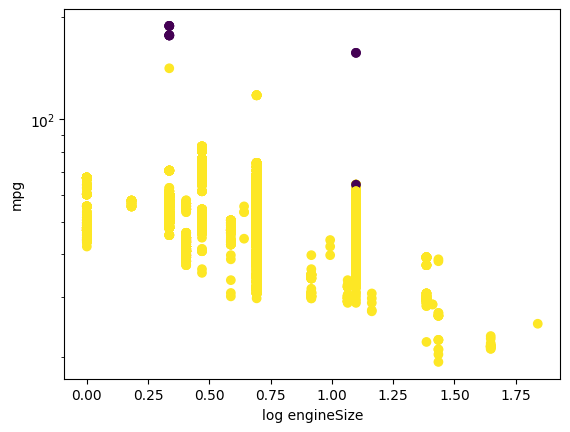

In [24]:
print((labels==-1).sum())

plt.scatter(np.log(data_train['price']),data_train['mpg'],c=labels)
plt.yscale('log')
plt.xlabel('log price')
plt.ylabel('mpg')
plt.show()

plt.scatter(np.log(data_train['mileage']),data_train['mpg'],c=labels)
plt.yscale('log')
plt.xlabel('log mileage')
plt.ylabel('mpg')
plt.show()

plt.scatter(np.log(data_train['engineSize']),data_train['mpg'],c=labels)
plt.yscale('log')
plt.xlabel('log engineSize')
plt.ylabel('mpg')
plt.show()

## Let's inspect the outliers found by the two methods

### DBSCAN OUTLIERS

In [25]:
data_train.loc[outliers_DBSCAN.astype(bool)].sort_values(by='mileage',ascending=False)

,model,year,price,mileage,tax,mpg,engineSize,Make,fuelType_Hybrid,fuelType_Petrol,transmission_Manual,transmission_Semi-Auto,serie_A,serie_Q,serie_RS,serie_TT,serie_S,serie_SQ,serie_R
9822,A6,2008,2490,323000,200.0,44.1,2.0,audi,0,0,1,0,1,0,0,0,0,0,0
9690,Q5,2011,6195,168017,200.0,42.1,2.0,audi,0,0,1,0,0,1,0,0,0,0,0
10112,A4,2008,3990,148000,305.0,35.8,3.0,audi,0,0,1,0,1,0,0,0,0,0,0
8270,Q5,2011,7495,139989,300.0,33.6,2.0,audi,0,1,1,0,0,1,0,0,0,0,0
10238,Q7,2009,8995,136000,540.0,31.0,3.0,audi,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4925,R8,2019,125000,500,145.0,21.4,5.2,audi,0,1,0,1,0,0,0,0,0,0,1
2255,R8,2020,137995,70,145.0,21.1,5.2,audi,0,1,0,1,0,0,0,0,0,0,1
364,A6,2019,29490,20,145.0,55.4,3.0,audi,0,0,0,1,1,0,0,0,0,0,0
4179,R8,2019,137500,10,150.0,21.4,5.2,audi,0,1,0,1,0,0,0,0,0,0,1


### LOF OUTLIERS

In [26]:
data_train.loc[outliers_LOF.astype(bool)]

,model,year,price,mileage,tax,mpg,engineSize,Make,fuelType_Hybrid,fuelType_Petrol,transmission_Manual,transmission_Semi-Auto,serie_A,serie_Q,serie_RS,serie_TT,serie_S,serie_SQ,serie_R
10656,A3,2016,15495,52500,0.0,176.6,1.4,audi,1,0,0,1,1,0,0,0,0,0,0
4261,A3,2015,17990,14000,0.0,188.3,1.4,audi,1,0,0,0,1,0,0,0,0,0,0
5981,Q7,2016,34999,36461,0.0,156.9,3.0,audi,0,0,0,1,0,1,0,0,0,0,0
4493,A3,2014,15490,24597,0.0,188.3,1.4,audi,1,0,0,0,1,0,0,0,0,0,0
4559,A3,2015,16000,48954,0.0,176.6,1.4,audi,1,0,0,1,1,0,0,0,0,0,0
3106,A3,2015,14981,28294,0.0,188.3,1.4,audi,1,0,0,1,1,0,0,0,0,0,0
5717,A3,2016,18900,18486,0.0,176.6,1.4,audi,1,0,0,1,1,0,0,0,0,0,0
4879,A3,2014,15000,24597,0.0,188.3,1.4,audi,1,0,0,1,1,0,0,0,0,0,0
5666,Q7,2016,37999,36461,0.0,156.9,3.0,audi,0,0,0,0,0,1,0,0,0,0,0
10185,A3,2015,11240,89000,0.0,176.6,1.4,audi,1,0,0,0,1,0,0,0,0,0,0


### Choosing an outlier strategy

Outlier detection is rarely completely objective.  
Different methods may flag different observations, especially when the data have irregular shapes or varying densities.

For this reason, the decision is not based only on the numerical output of the algorithm, but also on the visual plausibility of the detected points and careful inspection of the outlier candidates.

This is a good reminder that EDA is both a computational and an interpretative task.

This time, I believe that DBSCAN does a better job at identifying weird values. In my opinion actually a single record looks suspicious at it shows a huge mileage value. However, let's trust DBSCAN and remove also the other ones. 

In [27]:
data_train=data_train.loc[(1-outliers_DBSCAN).astype(bool)]

## 8. Inspecting feature transformations

Given that this course is not about ML, we would like to use the simplest model for predicting car price: Linear regression. 
This model works under the assumption that the relationship between features and target is linear and when extreme skewness is reduced.

For this reason, we inspect whether some numerical variables may benefit from transformations such as the logarithm (or Box Cox if the relation is still not linear).


The purpose is not to force the data into a perfect shape, but to obtain a representation that is more suitable for modeling.

As we aim to predict car price using a linear regression model, we need to inspect the dataset so to understand whether variable distribution is suited for the task


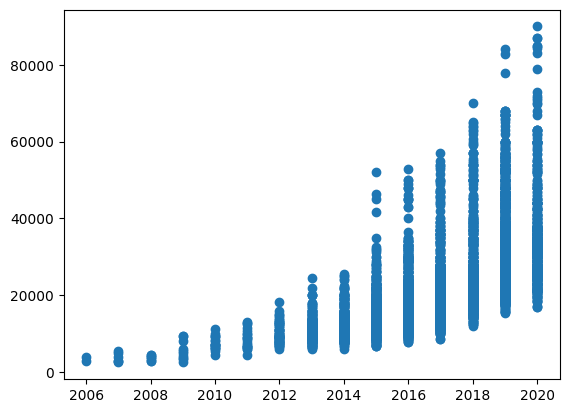

try to apply log transformation. As it does not depend on ANY parameter, it can be applied to both the training and test set.


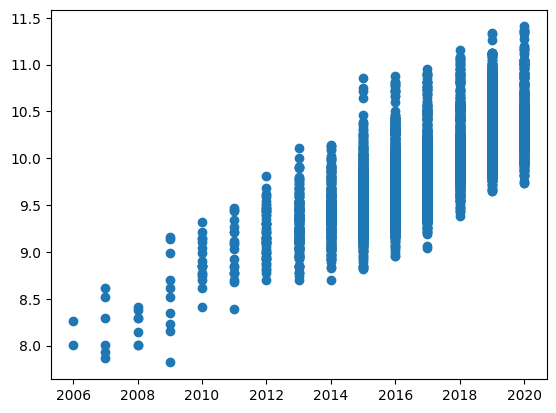

In [28]:
print('As we aim to predict car price using a linear regression model, we need to inspect the dataset so to understand whether variable distribution is suited for the task')

plt.scatter(data_train['year'],data_train['price'])
plt.show()

print('try to apply log transformation. As it does not depend on ANY parameter, it can be applied to both the training and test set.')
plt.scatter(data_train['year'],np.log(data_train['price']))
plt.show()

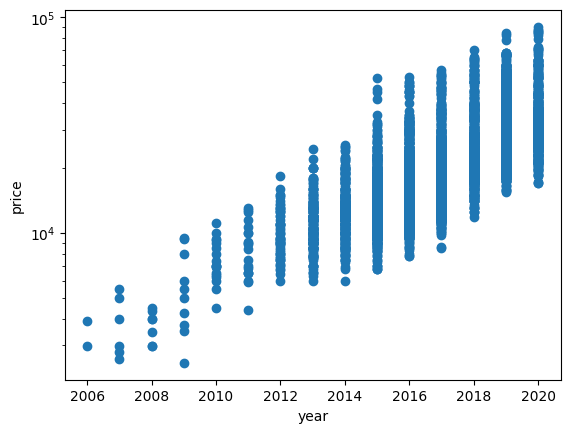

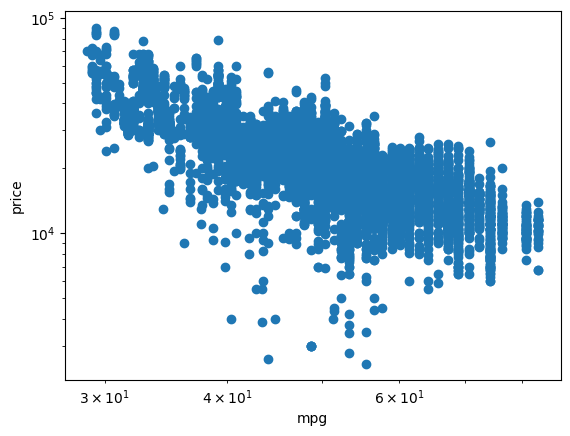

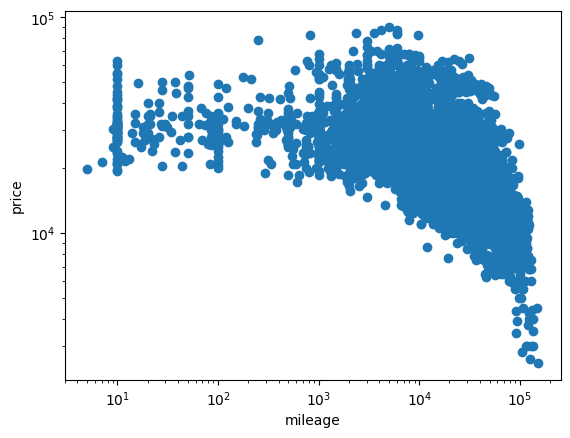

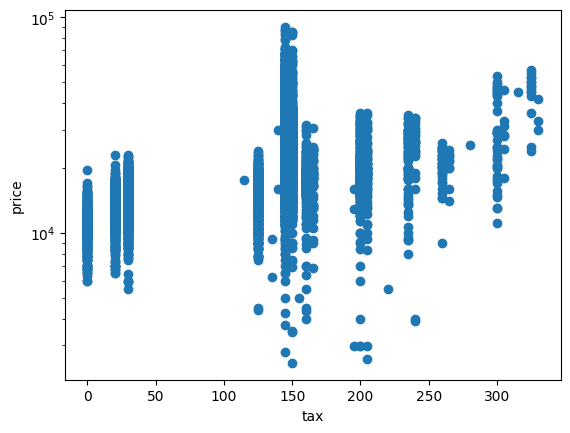

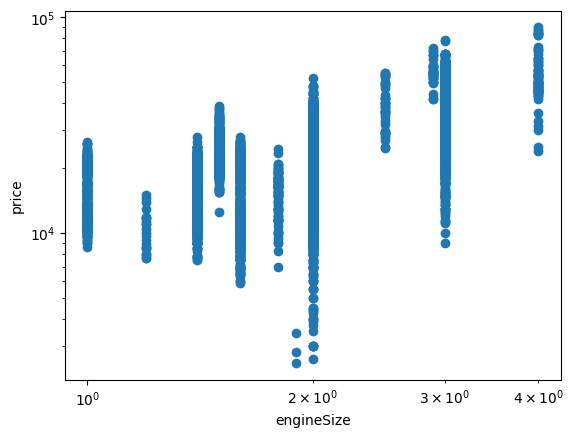

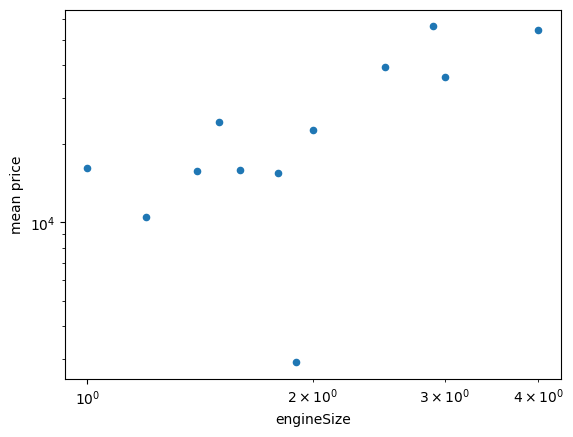

In [29]:
# try to apply log transformation. As it does not depend on ANY parameter, it can be applied to both the training and test set.
plt.scatter(data_train['year'],data_train['price'])
plt.xlabel('year')
plt.ylabel('price')
plt.yscale('log')
plt.show()

plt.scatter(data_train['mpg'],data_train['price'])
plt.xlabel('mpg')
plt.ylabel('price')
plt.yscale('log')
plt.xscale('log')
plt.show()

plt.scatter(data_train['mileage'],data_train['price'])
plt.xlabel('mileage')
plt.ylabel('price')
plt.xscale('log')
plt.yscale('log')
plt.show()

plt.scatter(data_train['tax'],data_train['price'])
plt.xlabel('tax')
plt.ylabel('price')
plt.yscale('log')
plt.show()

plt.scatter(data_train['engineSize'],data_train['price'])
plt.xlabel('engineSize')
plt.ylabel('price')
plt.yscale('log')
plt.xscale('log')
plt.show()

data_train[['engineSize','price']].groupby('engineSize').mean().reset_index().plot(kind='scatter',x='engineSize',y='price')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('engineSize')
plt.ylabel('mean price')
plt.show()

In [30]:
to_log=['price','mpg','engineSize']
no_log=['mileage','tax','year']

for var in to_log:
  data_train[f'log_{var}']=np.log(data_train[var])

In [31]:
binary_vars=['serie_A', 'serie_Q', 'serie_RS', 'serie_TT', 'serie_S', 'serie_SQ',
       'serie_R', 'fuelType_Hybrid', 'fuelType_Petrol', 'transmission_Manual',
       'transmission_Semi-Auto']


## 9. Which predictors seem most useful?

After preparing the variables, we want to understand which ones appear most associated with the target. We already checked numerical covariates using the correlation heatmap. Those were all showing non-negligible correlation. 

We now check target association with binary predictors using the **point-biserial correlation**. 

This helps us identify which engineered or encoded categorical features may carry predictive information about price in isolation (not as a group).

Indeed, as some dummy variables correspond to very rare categories or show weak association with the target, we remove remove them from the feature set to keep the model simple and interpretable.

This choice is heuristic and mainly intended to reduce dimensionality; in practice, regularized models (Lasso/Ridge) would handle this more systematically.
*SUBJECTIVE*: variables not having enough supprot or that correlate very poorly with the target are dropped: I choose a threshold of 0.2


In [32]:
## First of all, let us consider the correlation with the target. We need to use point
## biserial method so to compare binary variables with the continuous target
## ARBITRARY: variables that correlate very poorly may be dropped: I choose a threshold of 0.3

from scipy.stats import pointbiserialr
threshold=0.2
binary_for_regressions=[]

for attribute in binary_vars:
  r,p_value=pointbiserialr(data_train['price'], data_train[attribute])
  if p_value<0.05:
    print(f'Result of the test is meaningful. Correlation between PRICE and {attribute}: {r}')
    if np.abs(r)>threshold:
      binary_for_regressions.append(attribute)
  else:
    print(f'We cannot say anything about the correlation between PRICE and {attribute}')

Result of the test is meaningful. Correlation between PRICE and serie_A: -0.386683509250354
Result of the test is meaningful. Correlation between PRICE and serie_Q: 0.34680102283558
Result of the test is meaningful. Correlation between PRICE and serie_RS: 0.24013354081672308
We cannot say anything about the correlation between PRICE and serie_TT
We cannot say anything about the correlation between PRICE and serie_S
We cannot say anything about the correlation between PRICE and serie_SQ
We cannot say anything about the correlation between PRICE and serie_R
We cannot say anything about the correlation between PRICE and fuelType_Hybrid
Result of the test is meaningful. Correlation between PRICE and fuelType_Petrol: -0.05611965844644362
Result of the test is meaningful. Correlation between PRICE and transmission_Manual: -0.5066870011522877
Result of the test is meaningful. Correlation between PRICE and transmission_Semi-Auto: 0.2793601027215791


/Users/veronicaguidetti/miniforge3/envs/PACS/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


In [33]:
# Variables which survived
binary_for_regressions

['serie_A',
 'serie_Q',
 'serie_RS',
 'transmission_Manual',
 'transmission_Semi-Auto']

## 10. Feature scaling

Some variables have very different numerical ranges.  
For example, mileage can be much larger in magnitude than other predictors.

To reduce the influence of scale differences, we apply **Robust Scaling** which is less sensitive to different distribution skewness.

Importantly, the scaler must be **fitted on the training set only** and then applied to the test set using the same parameters.

In [34]:
# let us now define features and target variables and keep only relevant columns in the loop
target='log_price'
features=binary_for_regressions+[f'log_{var}' for var in to_log]+no_log
features.remove(target)

for var in to_log: #create log columns also for the test set
    data_test[f'log_{var}']=np.log(data_test[var])

data_train=data_train[features+[target]]
data_test = data_test[features+[target]]

In [35]:
#we now apply the Robust Scaler, this should be calibrated on the TRAINING SET ONLY
# the same transformation without fit should be also applied to the test set for consistency
from sklearn.preprocessing import RobustScaler
to_rescale=[f'log_{var}' for var in to_log]+no_log #numerical columns

scaler = RobustScaler()
transformed_data_train=data_train.copy()
transformed_data_train[to_rescale] = scaler.fit_transform(data_train[to_rescale])

transformed_data_test=data_test.copy()
transformed_data_test[to_rescale] = scaler.transform(data_test[to_rescale])

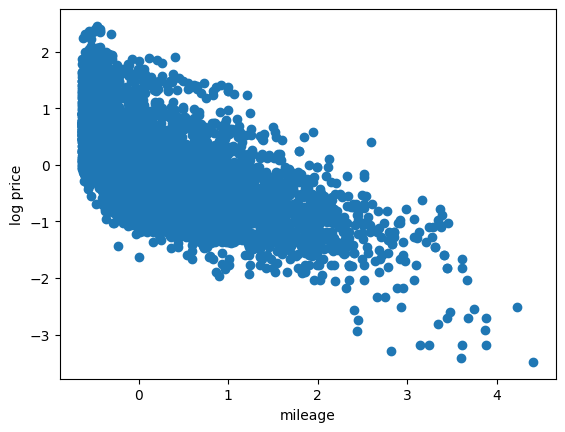

In [36]:
# linear relation is not spoiled by the rescaling
plt.scatter(transformed_data_train['mileage'],transformed_data_train['log_price'])
plt.xlabel('mileage')
plt.ylabel('log price')
plt.show()

### Define transformed training and test sets to be fed to the predictive model

In [37]:
# Define independent variable set (X) and target variable (y) to be used in the linear regression
X_train=transformed_data_train[features]
y_train=transformed_data_train[target]

X_test=transformed_data_test[features]
y_test=transformed_data_test[target]

In [38]:
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.linear_model import LinearRegression


lr = LinearRegression()
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

MAE=mean_absolute_error(y_test,y_pred)
print(f'The Mean Absolute Error of the regression is {MAE}.')
print(f'The R2 coefficient of the regression is {r2_score(y_test,y_pred)}.')

The Mean Absolute Error of the regression is 0.18240799787262094.
The R2 coefficient of the regression is 0.9070777886886114.


## 17. Evaluating the regression model

After fitting the model, we evaluate its predictive performance on the test set.

One common metric is the **coefficient of determination**, or **R-squared**:

$$
R^2 = 1 - \frac{SS_{\mathrm{res}}}{SS_{\mathrm{tot}}}
$$

where:

- $SS_{\mathrm{res}}$ is the sum of squared residuals
- $SS_{\mathrm{tot}}$ is the total sum of squares

In words, $R^2$ measures the proportion of the variability in the target that is explained by the model.

We also consider the **mean absolute error (MAE)**, which is often easier to interpret because it is expressed in the same units as the target variable after back-transformation.


#### *Final assessment*
What is the actual error on the price prediction? 
Invert scaling using scaler.inverse_transform(data_to_scale_back) and then compute the exponential. We need to apply the inverse transformation on the test set and on the prediction, to get a fair idea of the actual price MAE.

In [39]:
## Compute the price associated to prediction
predicted_df=transformed_data_test[to_rescale].copy()
predicted_df['log_price']=y_pred
predicted_df[to_rescale]=scaler.inverse_transform(predicted_df[to_rescale])
predicted_df['price']=np.exp(predicted_df['log_price'])

## Compute the price associated to prediction
true_price=np.exp(data_test['log_price'])

relative_MAE=mean_absolute_error(true_price,predicted_df['price'])

print(f'The relative MAE in predicting used car price is: {round(MAE*100,2)}%')



The relative MAE in predicting used car price is: 18.24%


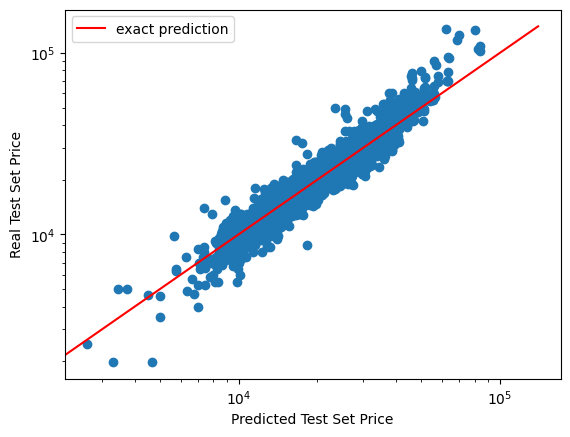

In [40]:
plt.scatter(predicted_df['price'],true_price)
plt.ylabel('Real Test Set Price')
plt.xlabel('Predicted Test Set Price')
plt.xscale('log')
plt.yscale('log')
plt.plot(np.linspace(0,140000,30),np.linspace(0,140000,30),color='red', label='exact prediction')
plt.legend()
plt.show()

#### Excercise:
* Try avoid using variable rescaling/transformation before applying linear regression. How do the performance metric change?

